In [ ]:
"""
WEEK 3

This assignment has 4 parts:

1. Use this notebook to read in the training data and do an initial EDA (Exploratory data analysis). I'll keep this open ended, but try to understand the data on some level. For example, look at the distribution of labels, looks at a few examples of headlines, look at dates, etc. Try to get an intuitive understanding of the data.

2. Build a multi-class classifier model in this notebook. You can build this however you want - the only rule for the competition is to use CountVectorizer() in your final model in some way for vectorizing your data. But feel free to use it however you'd like. On top of that feel free to use any supervised learning model you'd like for classifying. Scikit learn is a great place to look but doesn't have to be from scikit-learn.

3. Include a short paragraph or so in your notebook discussing interesting findings from your model. What did it do well on? What did it not do well on? Why is this the case? This is the "explainability" part of a model. Provide metrics.

4. Apply the chosen model to the judge data set provided - "news_category_judge_data_wo_label.csv". This is the "predictive" part of the model.

Format for saving:
- Save as a csv file with two columns: 'id' (given in the judge data set) and 'prediction'.
- Call the file "{your_first_name}_{your_last_name}_week_3_submission.csv"

Send me the submission csv file via email when done. Save this notebook to your repo and add me to a PR.
"""

In [1]:
# Some imports to get you started if you want. You don't need to use any of these except CountVectorizer and probably pandas
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
data = pd.read_csv("news_category_data/news_category_data.csv", na_filter=False)

In [3]:
clf = TfidfVectorizer(norm=None, smooth_idf=False).fit_transform(data).toarray()

In [4]:
data.category.value_counts()

category
POLITICS                          21222
WELLNESS                          14614
ARTS, CULTURE, & ENTERTAINMENT    12580
PARENTING                          7528
STYLE & BEAUTY                     7215
TRAVEL                             5879
INTERNATIONAL NEWS                 5701
FOOD & DRINK                       3811
QUEER VOICES                       3774
SPORTS                             2972
HOME & LIVING                      2561
ENVIRONMENT                        2395
WEDDINGS                           2138
DIVORCE                            2010
RELIGION                           1537
EDUCATION                          1313
SCIENCE                            1308
TECH                               1266
Name: count, dtype: int64

In [5]:
data.headline

0             How Trusting Your Gut Can Increase Wellbeing
1        Marc Chagall Birthday: Celebrating The Dreamy ...
2                            Interview With a Meal Planner
3                            Love Letters: Kenai Peninsula
4        American The U.S. Holds 'Incommunicado' Wants ...
                               ...                        
99819           Produce You Should Never Put In The Fridge
99820    Fix Up Your Home In A Weekend With These 6 DIY...
99821    Here's Why Many Americans Are Choosing Not To ...
99822            First Uterus Transplant In The U.S. Fails
99823                           The Spirit of Philadelphia
Name: headline, Length: 99824, dtype: object

In [6]:
news_clf = CountVectorizer(stop_words='english')
X = news_clf.fit_transform(data['headline'].values)

In [7]:
news_clf.vocabulary_

{'trusting': 38179,
 'gut': 16316,
 'increase': 18457,
 'wellbeing': 40338,
 'marc': 22583,
 'chagall': 6542,
 'birthday': 4189,
 'celebrating': 6418,
 'dreamy': 11380,
 'work': 40848,
 'expressionist': 13111,
 'great': 15978,
 'photos': 27690,
 'interview': 18975,
 'meal': 23137,
 'planner': 27982,
 'love': 21945,
 'letters': 21332,
 'kenai': 20142,
 'peninsula': 27335,
 'american': 1693,
 'holds': 17423,
 'incommunicado': 18438,
 'wants': 40021,
 'aclu': 888,
 'challenge': 6570,
 'detention': 10284,
 'donald': 11126,
 'trump': 38145,
 'supporters': 36078,
 'chicago': 6851,
 'violence': 39656,
 '10': 18,
 'best': 3949,
 'holiday': 17428,
 'party': 27010,
 'dips': 10585,
 'time': 37352,
 'order': 26190,
 'america': 1692,
 'model': 24045,
 'fires': 13908,
 'nigel': 25297,
 'barker': 3352,
 'jay': 19444,
 'manuel': 22544,
 'alexander': 1468,
 'poll': 28250,
 'deepak': 9760,
 'chopra': 6994,
 'quest': 29571,
 'god': 15639,
 'maybe': 22968,
 'stick': 35368,
 'tweeting': 38357,
 'holidays':

C:\Users\Nathan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


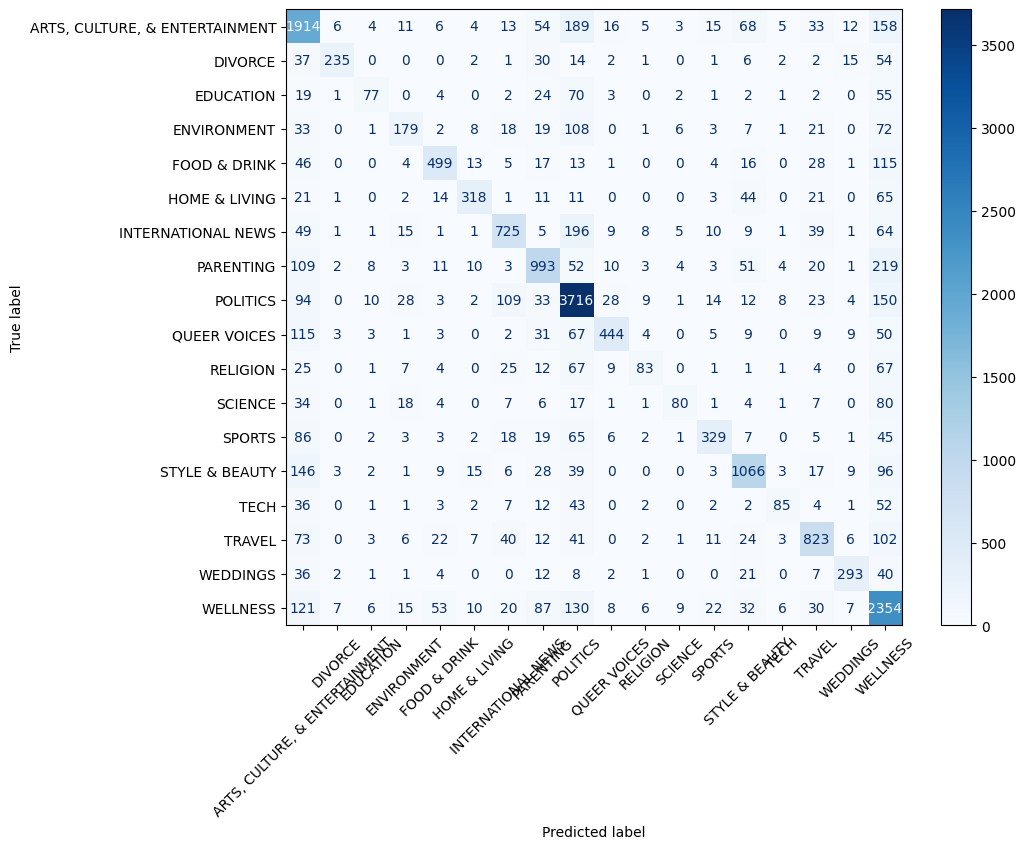

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


X = data['headline']          
y = data['category']      

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Vectorize the text with Tfidf
vectorizer = TfidfVectorizer(
    stop_words='english',   # still fine
    max_features=10_000,    # optional cap on vocab size
    norm='l2',              # default is 'l2'; you can also choose None or 'l1'
    smooth_idf=True         # default is True; set False if you want “traditional”
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

#Train a Logistic Regression Classifier
clf = LogisticRegression(
    multi_class='multinomial', 
    solver='lbfgs', 
    max_iter=1000
)

clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

plt.figure(figsize=(10, 8))  
disp.plot(cmap="Blues", xticks_rotation=45, ax=plt.gca())
plt.show()

In [11]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
print(classification_report(y_test, y_pred))

                                precision    recall  f1-score   support

ARTS, CULTURE, & ENTERTAINMENT       0.64      0.76      0.69      2516
                       DIVORCE       0.90      0.58      0.71       402
                     EDUCATION       0.64      0.29      0.40       263
                   ENVIRONMENT       0.61      0.37      0.46       479
                  FOOD & DRINK       0.77      0.65      0.71       762
                 HOME & LIVING       0.81      0.62      0.70       512
            INTERNATIONAL NEWS       0.72      0.64      0.68      1140
                     PARENTING       0.71      0.66      0.68      1506
                      POLITICS       0.77      0.88      0.82      4244
                  QUEER VOICES       0.82      0.59      0.69       755
                      RELIGION       0.65      0.27      0.38       307
                       SCIENCE       0.71      0.31      0.43       262
                        SPORTS       0.77      0.55      0.64  

In [12]:
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7118958176809417


### Model Evaluation

So, it seems to me that the model did the best with Politics, which makes sense because that category has the largest number of training examples and a fairly distinctive vocabulary like with election-related terms. Categories like Education, Environment, and Tech show much lower recall and F1-scores, making them harder to separate from other topics. Overall accuracy of about 72 % is reasonable for a simple bag-of-words logistic regression model, but the uneven per-class performance highlights that adding more training data or richer features (like bigrams or TF-IDF weighting) could help under-represented or more ambiguous categories.

In [ ]:
judge = pd.read_csv("news_category_data/news_category_judge_data_wo_label.csv", na_filter=False)


X_judge = vectorizer.transform(judge['headline'] + " " + judge['short_description'])

judge_preds = clf.predict(X_judge)

judge['predicted_category'] = judge_preds
judge.to_csv("judge_predictions.csv", index=False)
